In [1]:
import os
os.environ['KERAS_BACKEND'] = "tensorflow"
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
import keras
import keras.layers as lay
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

2025-09-02 15:36:54.866454: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756827414.896738 3090958 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756827414.905875 3090958 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756827414.929400 3090958 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756827414.929426 3090958 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756827414.929429 3090958 computation_placer.cc:177] computation placer alr

In [2]:
(trainx,trainy),(valx,valy)= keras.datasets.imdb.load_data(num_words=10000)
trainx_ = trainx
valx_ = valx
trainx = keras.preprocessing.sequence.pad_sequences(trainx,maxlen=500)
valx = keras.preprocessing.sequence.pad_sequences(valx,maxlen=500)
train = tf.data.Dataset.from_tensor_slices((trainx,trainy)).cache().batch(2**11).prefetch(tf.data.AUTOTUNE)
val = tf.data.Dataset.from_tensor_slices((valx,valy)).cache().batch(2**11).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1756827423.587662 3090958 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10262 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:04:00.0, compute capability: 8.6


In [3]:
model = keras.Sequential([
    lay.InputLayer((500,)),
    lay.Embedding(input_dim=10000,output_dim=8),
    lay.GRU(2**5,activation='tanh'),
    lay.Dense(1,activation='sigmoid')
])
model.summary()
model.compile(
    optimizer=keras.optimizers.Adam(1e-3,.99),
    loss=keras.losses.BinaryCrossentropy('loss'),
    metrics=[keras.metrics.BinaryAccuracy('acc')]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 8)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         4,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,065 (328.38 KB)

 Trainable params: 84,065 (328.38 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
hist = model.fit(
    train,
    epochs=40,
    validation_data=val,
)

Epoch 1/40


/home/villeneve/venv311/lib/python3.11/site-packages/keras/src/backend/tensorflow/nn.py:789: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
I0000 00:00:1756827427.710262 3091012 cuda_dnn.cc:529] Loaded cuDNN version 90300


13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - acc: 0.5133 - loss: 0.6925 - val_acc: 0.5871 - val_loss: 0.6910
Epoch 2/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - acc: 0.6222 - loss: 0.6885 - val_acc: 0.6043 - val_loss: 0.6865
Epoch 3/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - acc: 0.6565 - loss: 0.6816 - val_acc: 0.6388 - val_loss: 0.6786
Epoch 4/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - acc: 0.6887 - loss: 0.6698 - val_acc: 0.6510 - val_loss: 0.6656
Epoch 5/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - acc: 0.7038 - loss: 0.6504 - val_acc: 0.6750 - val_loss: 0.6437
Epoch 6/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - acc: 0.7247 - loss: 0.6175 - val_acc: 0.7014 - val_loss: 0.6033
Epoch 7/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - acc: 0.7522 - loss: 0.5527 - val_acc: 0.7562 - val_loss: 0.5073
Epoch 8/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - acc: 0.7892 - loss: 0.4570 - val_acc: 0.7924 - val_loss: 0.4546
Epoch 9/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - acc: 0.8112 -

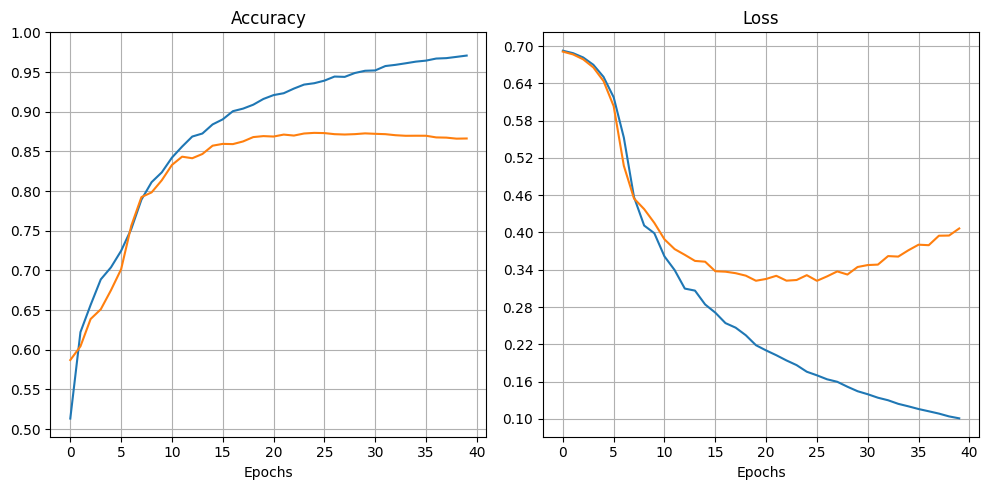

In [5]:
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax = ax.ravel()

ax[0].plot(hist.history['acc'])
ax[0].plot(hist.history['val_acc'])
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_yticks(np.linspace(.5,1,11))
ax[0].grid('both')

ax[1].plot(hist.history['loss'])
ax[1].plot(hist.history['val_loss'])
ax[1].set_title('Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_yticks(np.linspace(.7,.1,11))
ax[1].grid('both')

plt.tight_layout()
plt.show()

In [6]:
index = keras.datasets.imdb.get_word_index()
reversed_index = dict([(value,key) for (key,value) in index.items()])
def decoder_msg(reversed_index,data, item):
    return " ".join([reversed_index.get(i-3,"?") for i in data[item]])

In [ ]:
for i in range(5):
    r = np.random.randint(0,len(valy),())
    output = model.predict_on_batch(valx[r:r+1])
    print(decoder_msg(reversed_index,valx_,r)+f'\nReal_Score = {valy[r]}; Predict_Score = {output[0]}')

? i have mixed emotions about this film especially as it ? to its ? br br an american werewolf in london that film had it's funny moments it was still more of horror tale than anything else this updated version now set in paris does not have that edge at all and simply isn't in the same class but it does have some good things going for it that the first film did not have and overall it's still fun to watch br br so werewolf ? aside most of whom think this film is pure garbage compared to the london version i'll still give it decent marks since i don't care what others think i liked it even though i agree london is better and i prefer that version too br br the first 30 40 minutes of this movie is strictly played for laughs including a hysterical scene with a balloon in a restaurant it also introduces the lead female character played by julie ? i don't see enough of this actress she doesn't seem to make that many films or least ones i hear about over here in america this french actress 